<a href="https://colab.research.google.com/github/DhaviRodrigues/Projeto_PISI3_2026/blob/main/analise_head_tail_breaks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import os

sns.set_theme(style="whitegrid")

# 2. Ingestão e Limpeza de Dados
Carregamento do dataset do IMDb e remoção de valores nulos, mantendo os registros com zero votos para análise da Cauda Longa profunda.

In [30]:
arquivos = [f for f in os.listdir('/content') if f.endswith('.csv')]
caminho = '/content/' + arquivos[0]
df = pd.read_csv(caminho)

df.columns = [c.strip().lower() for c in df.columns]
col_votos = 'vote_count' if 'vote_count' in df.columns else [c for c in df.columns if 'vote' in c][0]

df = df.dropna(subset=[col_votos])
df_sorted = df.sort_values(by=col_votos, ascending=False).reset_index(drop=True)
df_sorted['Ranking'] = range(1, len(df_sorted) + 1)

# 3. Análise Estatística: Head/Tail Breaks
Cálculo da Média Aritmética Global para isolar a assimetria da distribuição e identificar o ponto de ruptura do mercado.

In [31]:
media_global = df_sorted[col_votos].mean()
corte_index = len(df_sorted[df_sorted[col_votos] >= media_global])

print(f"Total de filmes: {len(df_sorted):,}")
print(f"Média Global: {media_global:.2f} votos")
print(f"Ponto de Corte (Ranking): {corte_index:,}")

Total de filmes: 951,555
Média Global: 22.51 votos
Ponto de Corte (Ranking): 46,038


# 4. Visualização de Dados
Geração do gráfico semi-logarítmico (SymLog) para representação honesta do volume de obras mantendo a legibilidade da linha de média global.

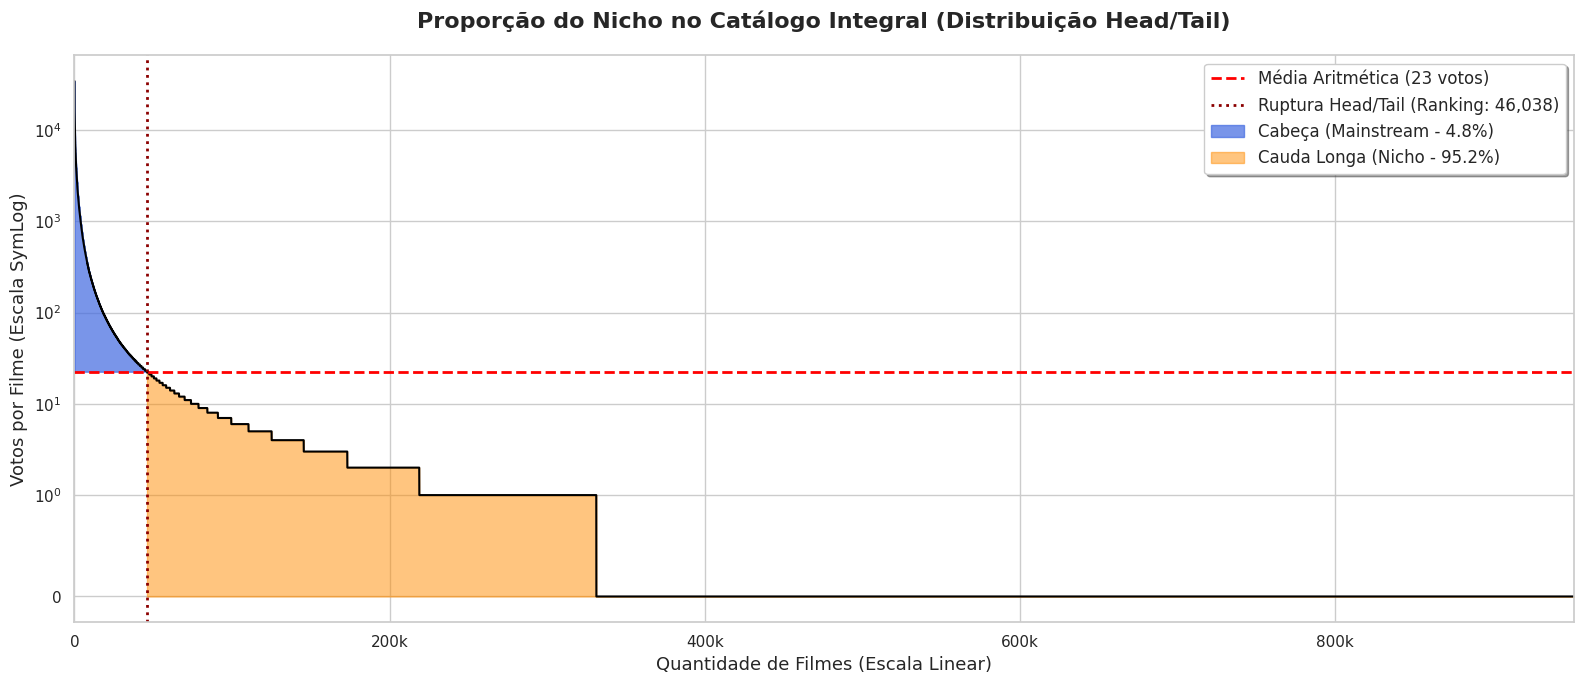

In [32]:
fig, ax = plt.subplots(figsize=(16, 7))
sns.lineplot(data=df_sorted, x='Ranking', y=col_votos, color='black', linewidth=1.5, ax=ax)

ax.set_yscale('symlog', linthresh=1)
ax.set_xlim(0, len(df_sorted))

ax.axhline(y=media_global, color='red', linestyle='--', linewidth=2, label=f'Média Aritmética ({media_global:.0f} votos)')
ax.axvline(x=corte_index, color='darkred', linestyle=':', linewidth=2, label=f'Ruptura Head/Tail (Ranking: {corte_index:,})')

ax.fill_between(df_sorted['Ranking'][:corte_index], df_sorted[col_votos][:corte_index], media_global, color='royalblue', alpha=0.7, label=f'Cabeça (Mainstream - {(corte_index/len(df_sorted))*100:.1f}%)')
ax.fill_between(df_sorted['Ranking'][corte_index:], df_sorted[col_votos][corte_index:], 0, color='darkorange', alpha=0.5, label=f'Cauda Longa (Nicho - {((len(df_sorted)-corte_index)/len(df_sorted))*100:.1f}%)')

formatter = FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x > 0 else '0')
ax.xaxis.set_major_formatter(formatter)

plt.title('Proporção do Nicho no Catálogo Integral (Distribuição Head/Tail)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Quantidade de Filmes (Escala Linear)', fontsize=13)
plt.ylabel('Votos por Filme (Escala SymLog)', fontsize=13)

plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()